In [4]:
list.files("/content")

[1] "complaints.csv" "customers.csv"  "deliveries.csv" "orders.csv"    
[5] "sample_data"

In [5]:
install.packages("sqldf")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
library(sqldf)

customers <- read.csv("/content/customers.csv")
orders <- read.csv("/content/orders.csv")
deliveries <- read.csv("/content/deliveries.csv")
complaints <- read.csv("/content/complaints.csv")

In [7]:
sqldf("
SELECT service_type, COUNT(*) as total_orders
FROM orders
GROUP BY service_type
")

service_type,total_orders
<chr>,<int>
Business,165
Medical,139
Parcel,308
Passenger,341
Retail,297


In [8]:
sqldf("
SELECT delivery_status,
AVG(customer_rating_post_delivery) as avg_rating
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_rating
<chr>,<dbl>
Delayed,3.114975
Failed,3.049313
OnTime,4.283273


In [9]:
sqldf("
SELECT complaint_type,
COUNT(*) as total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


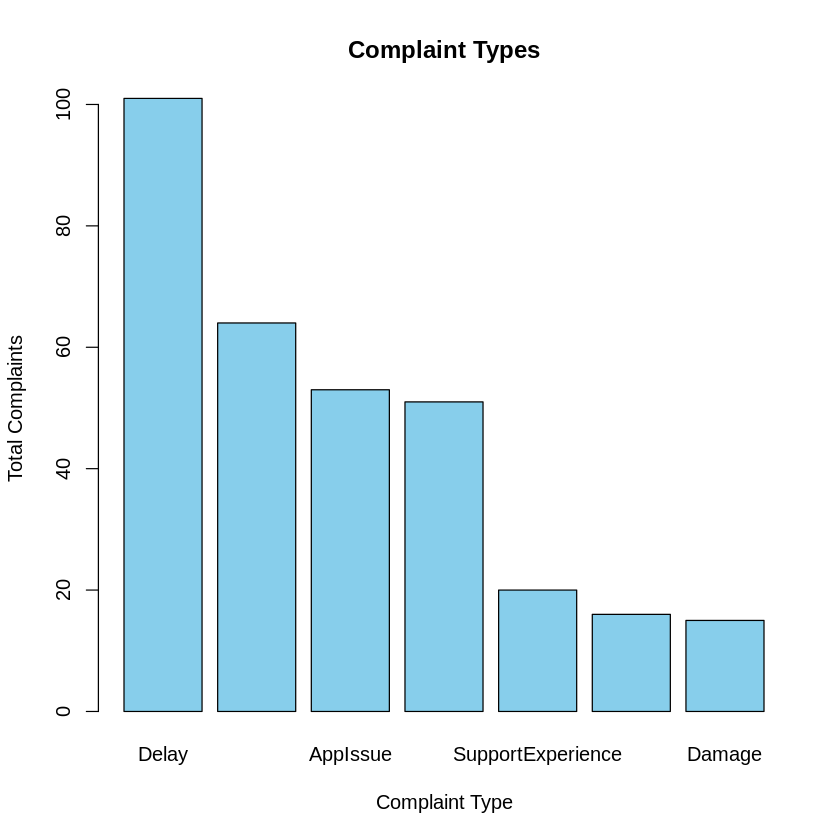

In [11]:
complaint_data <- sqldf("
SELECT complaint_type,
COUNT(*) as total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

barplot(
  complaint_data$total_complaints,
  names.arg = complaint_data$complaint_type,
  col = "skyblue",
  main = "Complaint Types",
  xlab = "Complaint Type",
  ylab = "Total Complaints"
)

In [12]:
sqldf("
SELECT delivery_id, delivery_status, customer_rating_post_delivery
FROM deliveries
WHERE delivery_status IN ('Delayed', 'Failed')
AND customer_rating_post_delivery < 3
ORDER BY customer_rating_post_delivery ASC
LIMIT 10
")

delivery_id,delivery_status,customer_rating_post_delivery
<chr>,<chr>,<dbl>
DL00017,Delayed,1.00
DL00259,Delayed,1.00
DL00288,Delayed,1.00
DL00479,Delayed,1.00
DL00509,Delayed,1.00
DL00558,Failed,1.00
DL00195,Delayed,1.04
DL00536,Failed,1.07
DL00392,Delayed,1.15


In [13]:
sqldf("
SELECT
  delivery_status,
  COUNT(*) AS total_deliveries,
  AVG(customer_rating_post_delivery) AS avg_rating,
  SUM(route_distance_km) AS total_distance
FROM deliveries
GROUP BY delivery_status
ORDER BY avg_rating DESC
")


delivery_status,total_deliveries,avg_rating,total_distance
<chr>,<int>,<dbl>,<dbl>
OnTime,616,4.283273,8486.24
Delayed,202,3.114975,2963.39
Failed,132,3.049313,1764.22


In [14]:
sqldf("
SELECT complaint_type, COUNT(*) AS total_complaints
FROM complaints
WHERE complaint_type LIKE '%Delay%'
GROUP BY complaint_type
")

complaint_type,total_complaints
<chr>,<int>
Delay,101


In [15]:
delivery_orders <- sqldf("
SELECT
  d.delivery_id,
  d.delivery_status,
  d.customer_rating_post_delivery,
  o.service_type,
  o.priority_level,
  o.order_value
FROM deliveries d
JOIN orders o
ON d.order_id = o.order_id
")

head(delivery_orders)

,delivery_id,delivery_status,customer_rating_post_delivery,service_type,priority_level,order_value
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1,DL00001,Failed,3.07,Business,Medium,151.14
2,DL00002,OnTime,5.00,Parcel,Medium,10.04
3,DL00003,OnTime,4.98,Medical,Medium,141.93
4,DL00004,Delayed,4.18,Medical,Low,11.11
5,DL00005,OnTime,4.18,Medical,High,76.02
6,DL00006,Delayed,1.57,Medical,Medium,190.94


In [16]:
sqldf("
SELECT
  service_type,
  delivery_status,
  COUNT(*) AS total
FROM delivery_orders
GROUP BY service_type, delivery_status
ORDER BY service_type, total DESC
")

service_type,delivery_status,total
<chr>,<chr>,<int>
Business,OnTime,73
Business,Delayed,28
Business,Failed,25
Medical,OnTime,70
Medical,Delayed,22
Medical,Failed,16
Parcel,OnTime,156
Parcel,Delayed,49
Parcel,Failed,25


In [17]:
summary(deliveries)

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id      dispatch_time delivery_completed_at  delivery_status
 Length   :950   Length   :950   Length   :950         Length   :950   
 N.unique :  8   N.unique :950   N.unique :932         N.unique :  3   
 N.blank  :  0   N.blank  :  0   N.blank  : 19         N.blank  :  0   
 Min.nchar:  3   Min.nchar: 19   Min.nchar:  0         Min.nchar:  6   
 Max.nchar:  3   Max.nchar: 19   Max.nchar: 26         Max.nchar:  7   
                                                

In [18]:
sample_df <- data.frame(
  service_type = c("Passenger", "Parcel"),
  total_orders = c(341, 308)
)

sample_df <- rbind(
  sample_df,
  data.frame(service_type = "Retail", total_orders = 297)
)

sample_df

service_type,total_orders
<chr>,<dbl>
Passenger,341
Parcel,308
Retail,297


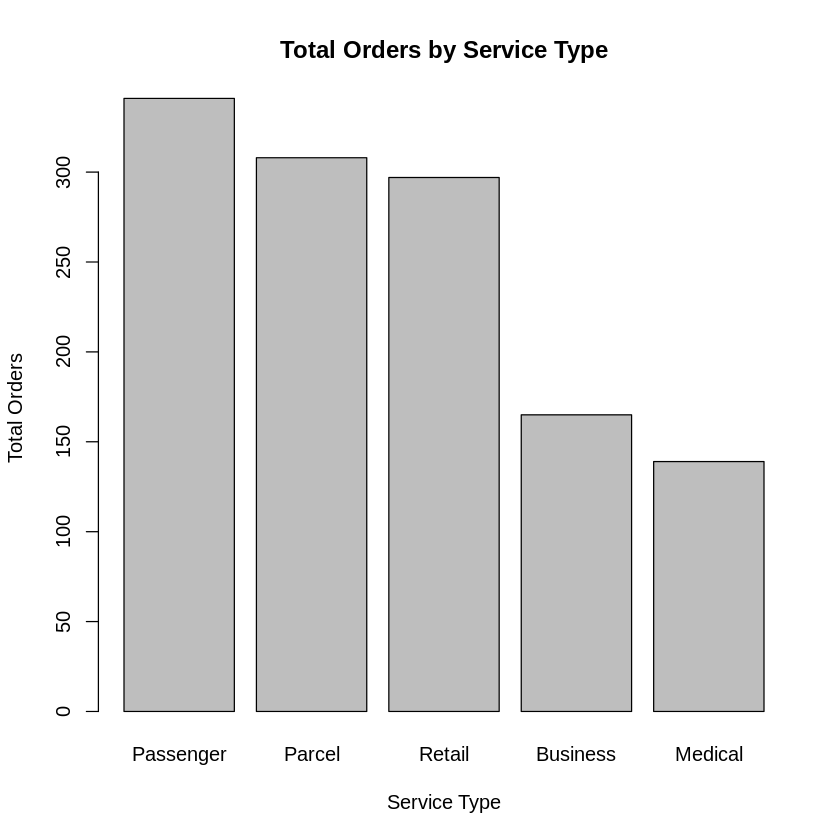

In [19]:
service_data <- sqldf("
SELECT service_type, COUNT(*) AS total_orders
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")

barplot(
  service_data$total_orders,
  names.arg = service_data$service_type,
  main = "Total Orders by Service Type",
  xlab = "Service Type",
  ylab = "Total Orders"
)